In [16]:
import numpy as np
from beliefppg import infer_hr
import pandas as pd
from scipy.signal import medfilt

In [17]:
feature_columns = ['ppg', 'acc_x', 'acc_y', 'acc_z']
label_columns = ['HR']

In [18]:
CHUNK_SIZE = 4800 # 2 minutes * 60 seconds * 40 samples/second = 4800 samples
SAMPLES_PER_LABEL = 320 # 8 seconds * 40 samples/second = 320 samples

In [19]:
def retrieve_subject_data(subject):
    feature_data = pd.read_csv(
        f"../../data/processed/callisia/{subject}/features.csv",
        usecols=feature_columns
    )
    label_data = pd.read_csv(
        f"../../data/processed/callisia/{subject}/labels.csv",
        usecols=label_columns
    )
    return feature_data, label_data

In [20]:
# 1. Define your list of subjects
# You can populate this manually or use os.listdir() to read folder names
subjects = ["P01", "P02", "P03", "P04", "P05"]

# Constants
FS = 40
CHUNK_SIZE = 4800
SAMPLES_PER_LABEL = 320

# 2. Master tracking variables for the entire dataset
subject_maes = {}       # Dictionary to store MAE for each subject
grand_all_preds = []    # Master list for EVERY prediction made
grand_all_truths = []   # Master list for EVERY ground truth label
subject_data = {}       # Dictionary to store predictions and truths for each subject

In [21]:
print("Starting Multi-Subject Pipeline...")

Starting Multi-Subject Pipeline...


In [22]:
# ==========================================
# OUTER LOOP: Iterate through each subject
# ==========================================
for subject in subjects:
    print(f"\nLoading data for {subject}...")

    try:
        data, label = retrieve_subject_data(subject)
    except Exception as e:
        print(f"Skipping {subject}: Could not load data. ({e})")
        continue

    total_samples = len(data)

    # Subject-level tracking
    subject_preds = []
    subject_truths = []

    # ==========================================
    # INNER LOOP: Process 2-minute chunks
    # ==========================================
    for start_idx in range(0, total_samples, CHUNK_SIZE):
        end_idx = min(start_idx + CHUNK_SIZE, total_samples)

        label_start_idx = start_idx // SAMPLES_PER_LABEL
        label_end_idx = end_idx // SAMPLES_PER_LABEL

        data_chunk = data.iloc[start_idx:end_idx]
        ppg_window = data_chunk[['ppg']].values
        acc_window = data_chunk[['acc_x', 'acc_y', 'acc_z']].values

        label_chunk = label.iloc[label_start_idx:label_end_idx]
        hr_gt = label_chunk[['HR']].values

        # Skip incomplete tails to prevent Keras crashes
        if len(ppg_window) < CHUNK_SIZE:
            break

        # Run Inference
        hr_predictions, midpoints = infer_hr(
            ppg=ppg_window,
            ppg_freq=FS,
            acc=acc_window,
            acc_freq=FS
        )

        # Format arrays
        preds = np.squeeze(hr_predictions)
        truths = np.squeeze(hr_gt)

        # Interpolate the 51 predictions to match the 15 ground truth labels
        gt_midpoints = np.arange(160, CHUNK_SIZE, 320)
        aligned_preds = np.interp(gt_midpoints, midpoints, preds)

        # Save to the subject's local lists
        subject_preds.extend(aligned_preds)
        subject_truths.extend(truths)

    # ==========================================
    # SUBJECT SUMMARY (Runs after inner loop finishes)
    # ==========================================
    sub_preds_arr = np.array(subject_preds)
    sub_truths_arr = np.array(subject_truths)

    if len(sub_preds_arr) > 0:
        smoothed_preds = medfilt(sub_preds_arr, kernel_size=7)

        # Calculate MAE for THIS subject
        sub_mae = np.mean(np.abs(smoothed_preds - sub_truths_arr))
        subject_maes[subject] = sub_mae

        # Store subject data for plotting later
        subject_data[subject] = {
            'predictions': smoothed_preds,
            'truths': sub_truths_arr
        }

        print(f"--> COMPLETED {subject} | Total Predictions: {len(smoothed_preds)} | MAE: {sub_mae:.2f} BPM")

        # Add this subject's data to the Grand Master lists
        grand_all_preds.extend(smoothed_preds)
        grand_all_truths.extend(subject_truths)
    else:
        print(f"--> COMPLETED {subject} | No valid 2-minute chunks found.")


Loading data for P01...
2/2 [==============================] - 1s 45ms/step
--> COMPLETED P01 | Total Predictions: 1080 | MAE: 3.79 BPM

Loading data for P02...
2/2 [==============================] - 1s 46ms/step
--> COMPLETED P02 | Total Predictions: 1050 | MAE: 7.82 BPM

Loading data for P03...
2/2 [==============================] - 1s 46ms/step
--> COMPLETED P03 | Total Predictions: 600 | MAE: 4.50 BPM

Loading data for P04...
2/2 [==============================] - 1s 44ms/step
--> COMPLETED P04 | Total Predictions: 1065 | MAE: 7.65 BPM

Loading data for P05...
2/2 [==============================] - 1s 41ms/step
--> COMPLETED P05 | Total Predictions: 1065 | MAE: 4.82 BPM


In [23]:
# ==========================================
# GRAND SUMMARY (Runs after all subjects finish)
# ==========================================
# Convert master lists to arrays
final_grand_preds = np.array(grand_all_preds)
final_grand_truths = np.array(grand_all_truths)

# Calculate the MAE across the entire dataset
overall_dataset_mae = np.mean(np.abs(final_grand_preds - final_grand_truths))

print("\n" + "="*50)
print("FINAL PIPELINE SUMMARY")
print("="*50)
print("PER-SUBJECT MAE:")
for sub, mae in subject_maes.items():
    print(f" - {sub}: {mae:.2f} BPM")

print("-" * 50)
print(f"TOTAL PREDICTIONS GENERATED: {len(final_grand_preds)}")
print(f"GRAND OVERALL MAE:           {overall_dataset_mae:.2f} BPM")
print("="*50)



FINAL PIPELINE SUMMARY
PER-SUBJECT MAE:
 - P01: 3.79 BPM
 - P02: 7.82 BPM
 - P03: 4.50 BPM
 - P04: 7.65 BPM
 - P05: 4.82 BPM
--------------------------------------------------
TOTAL PREDICTIONS GENERATED: 4860
GRAND OVERALL MAE:           5.82 BPM


In [24]:
# ==========================================
# PART 2: VISUALIZATION - Per-Subject Plots Using Stored Data
# ==========================================
import matplotlib.pyplot as plt


In [25]:
def plot_subject_predictions(subject, subject_data_dict):
    """Create comparison plot using stored predictions and truths for a subject."""
    try:
        preds = subject_data_dict[subject]['predictions']
        truths = subject_data_dict[subject]['truths']

        fig, ax = plt.subplots(figsize=(16, 6))

        time_points = np.arange(len(truths))

        # Plot real (ground truth) HR
        ax.plot(time_points, truths, color='blue', linewidth=2.0,
                alpha=0.8, label='Real HR (Ground Truth)', marker='o', markersize=4)

        # Plot predicted HR
        ax.plot(time_points, preds, color='red', linewidth=2.0,
                alpha=0.7, label='Predicted HR (BeliefPPG)', linestyle='--', marker='s', markersize=3)

        ax.set_xlabel('Time Point (8-second windows)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Heart Rate (bpm)', fontsize=12, fontweight='bold')

        # Calculate metrics
        mae = np.mean(np.abs(preds - truths))
        rmse = np.sqrt(np.mean((preds - truths) ** 2))
        correlation = np.corrcoef(truths, preds)[0, 1]

        metrics_text = f"MAE: {mae:.2f} bpm | RMSE: {rmse:.2f} bpm | Correlation: {correlation:.3f}"
        ax.set_title(f'{subject} - Predicted vs Real HR\n{metrics_text}',
                     fontsize=13, fontweight='bold')

        ax.legend(loc='best', fontsize=11)
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        return fig, mae, rmse, correlation

    except Exception as e:
        print(f"Error creating plot for {subject}: {e}")
        return None, None, None, None



GENERATING PREDICTED VS REAL HR PLOTS FOR EACH SUBJECT

P01:
  MAE:         3.79 bpm
  RMSE:        7.11 bpm
  Correlation: 0.573



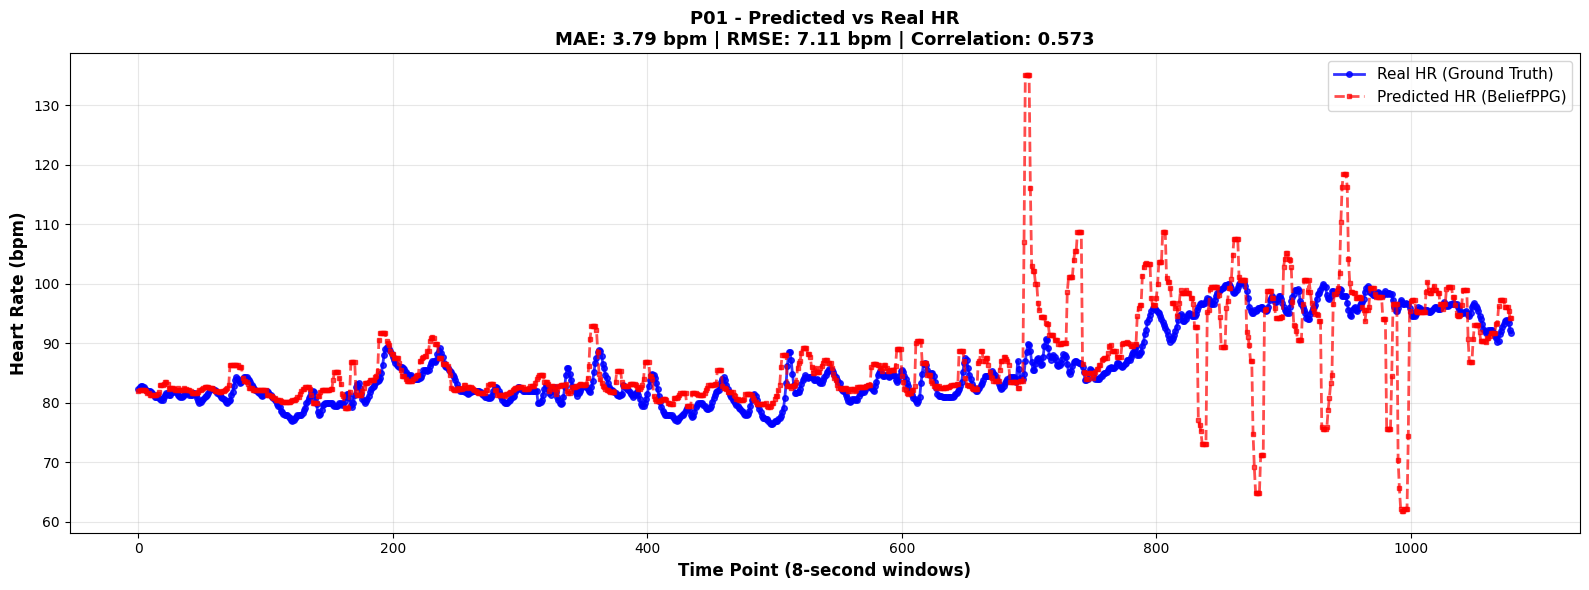

P02:
  MAE:         7.82 bpm
  RMSE:        11.91 bpm
  Correlation: 0.439



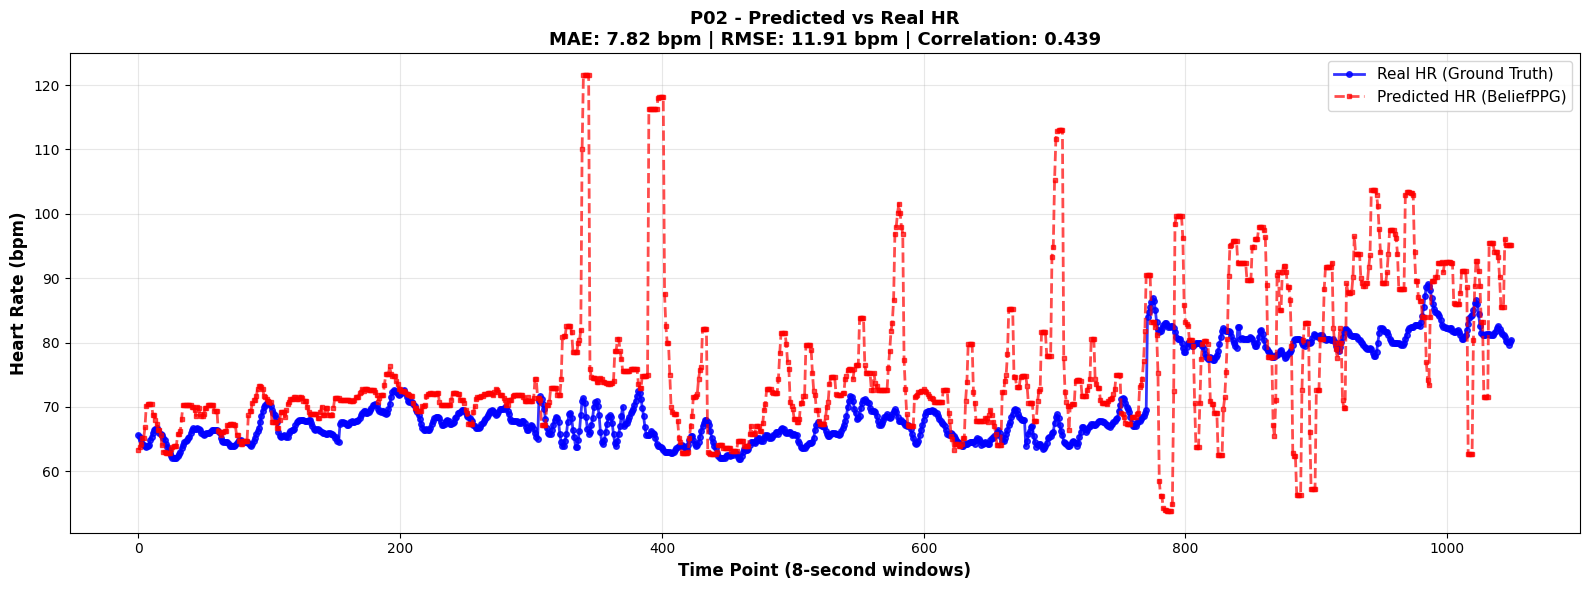

P03:
  MAE:         4.50 bpm
  RMSE:        8.17 bpm
  Correlation: 0.576



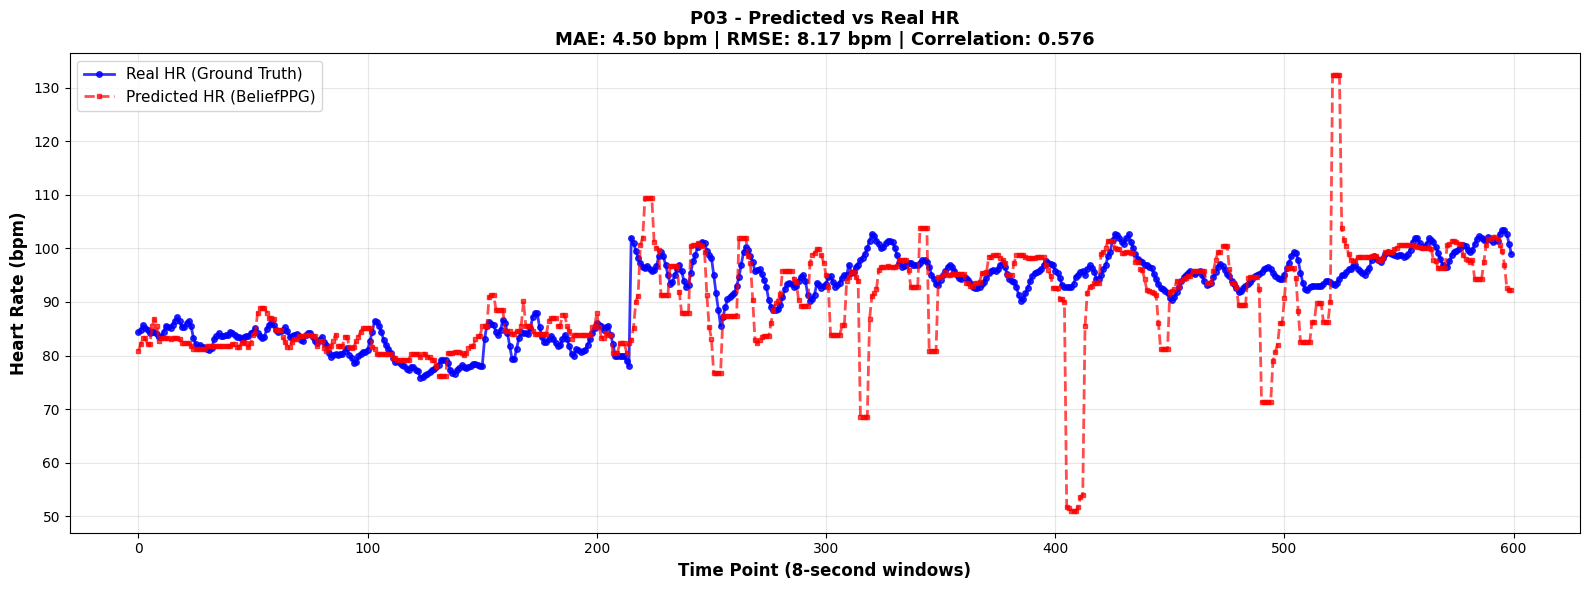

P04:
  MAE:         7.65 bpm
  RMSE:        11.09 bpm
  Correlation: 0.745



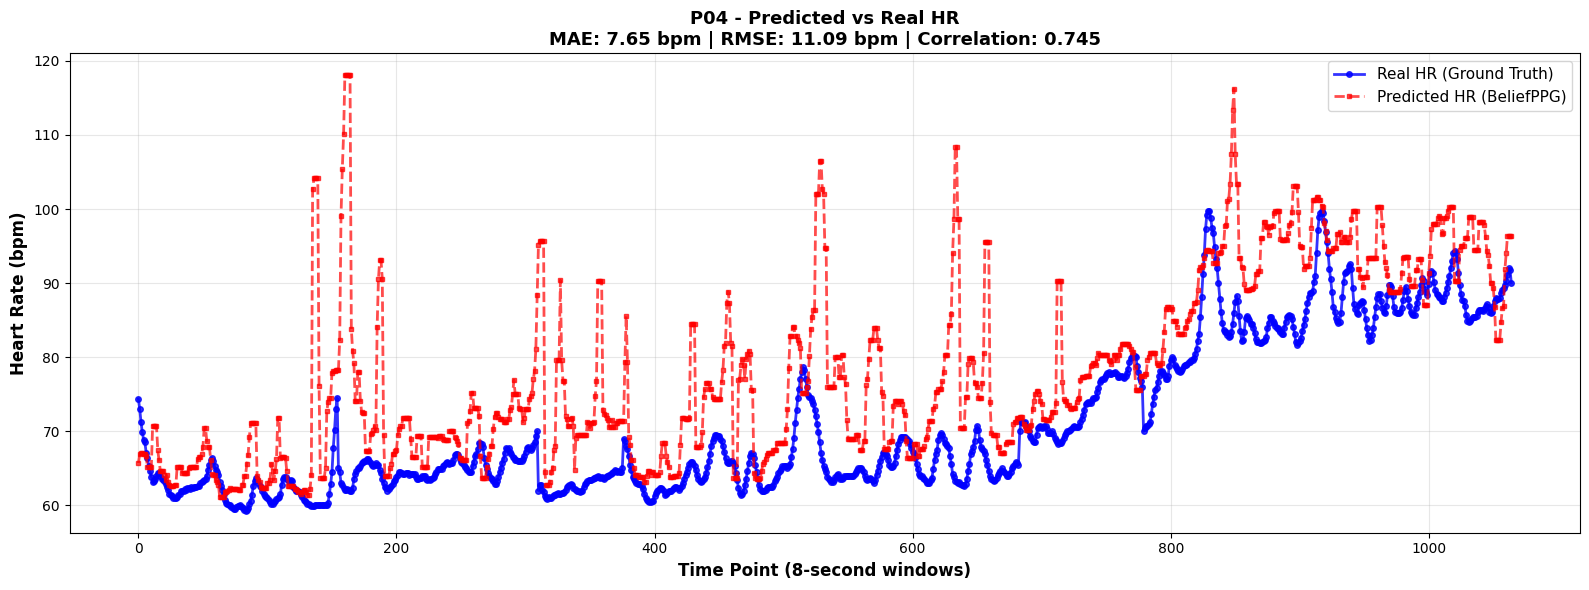

P05:
  MAE:         4.82 bpm
  RMSE:        7.12 bpm
  Correlation: 0.684



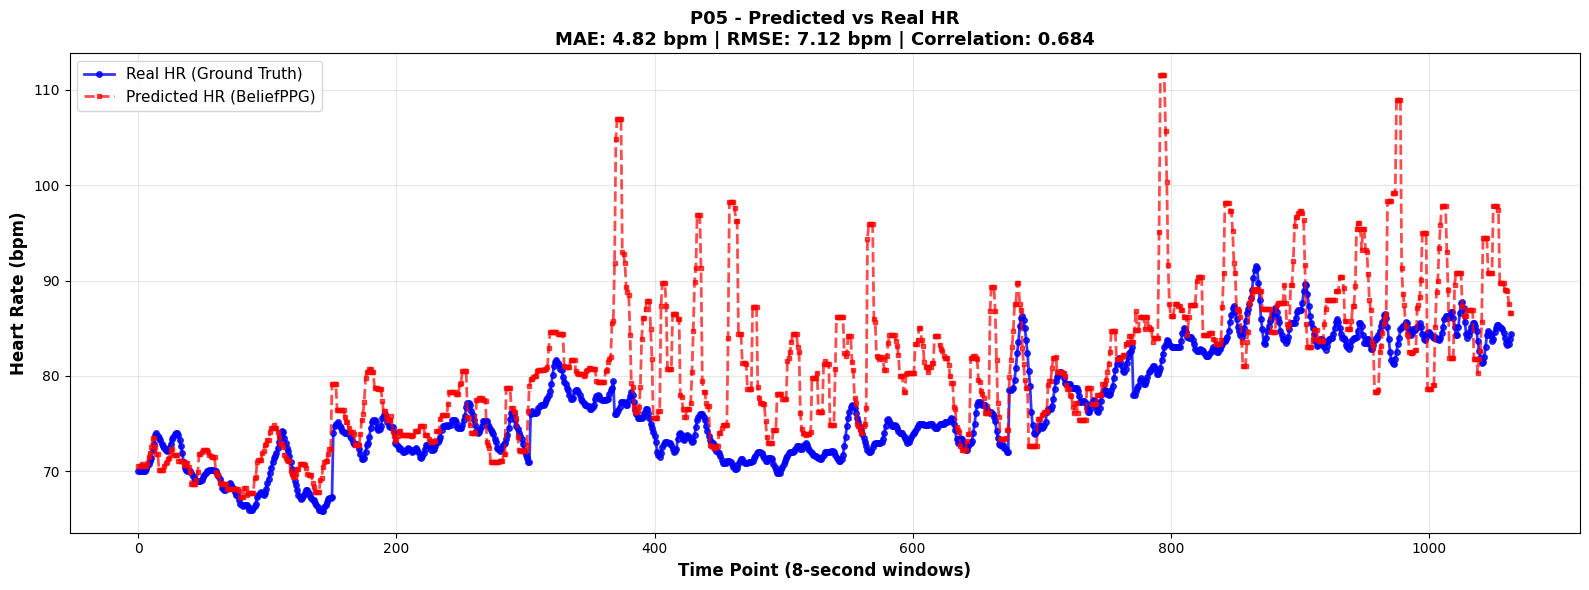

In [26]:
print("\n" + "="*60)
print("GENERATING PREDICTED VS REAL HR PLOTS FOR EACH SUBJECT")
print("="*60 + "\n")

for subject in subjects:
    if subject in subject_data:
        fig, mae, rmse, corr = plot_subject_predictions(subject, subject_data)

        if fig is not None:
            print(f"{subject}:")
            print(f"  MAE:         {mae:.2f} bpm")
            print(f"  RMSE:        {rmse:.2f} bpm")
            print(f"  Correlation: {corr:.3f}\n")
            plt.show()
    else:
        print(f"{subject}: No data available\n")

print("="*60 + "\n")


✓ Displaying grand comparison plot



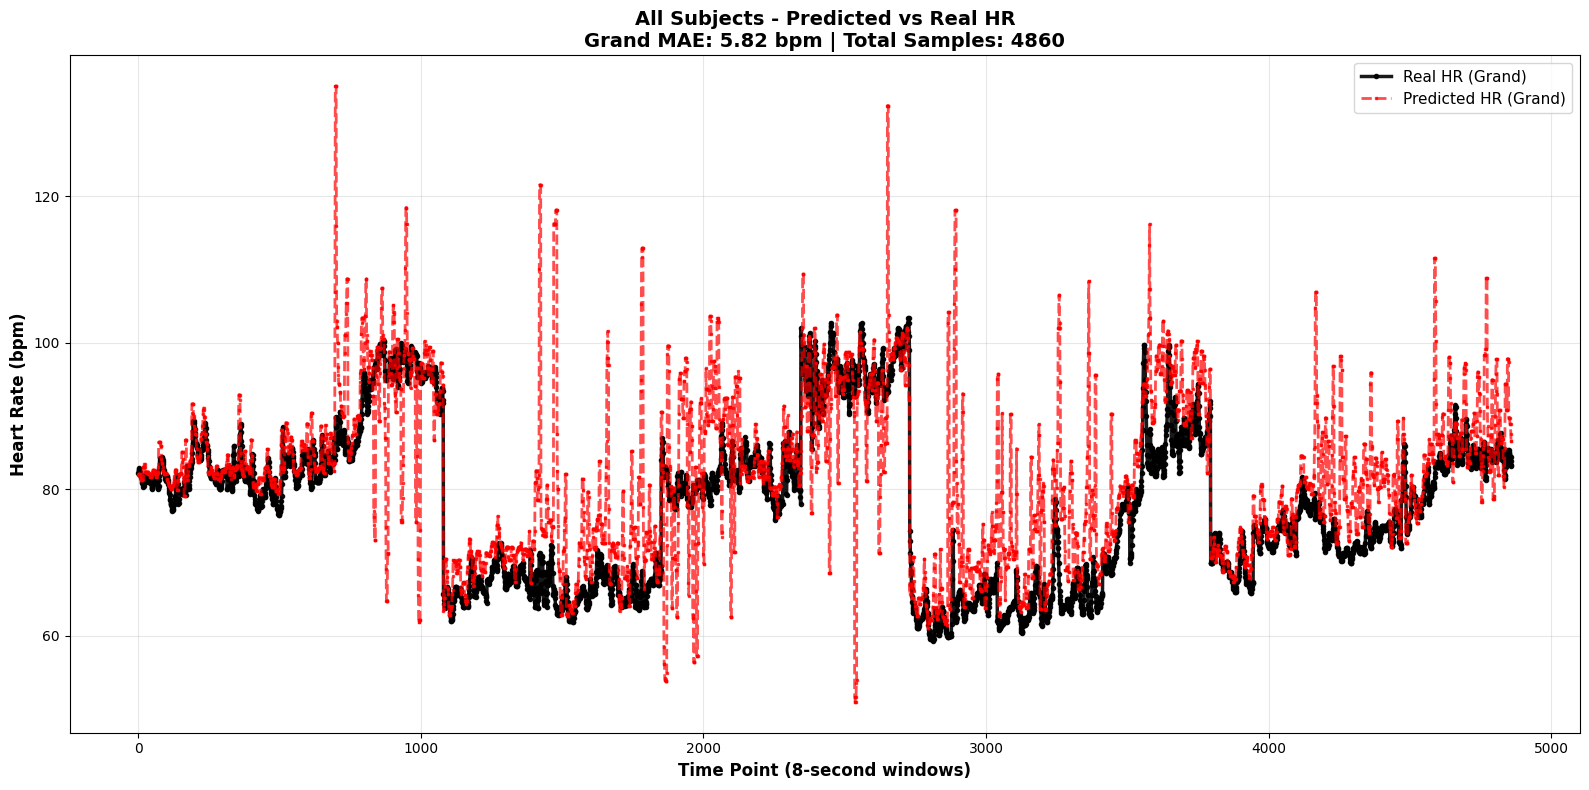

In [27]:
# Create grand comparison plot (all subjects on one plot)
fig, ax = plt.subplots(figsize=(16, 8))

time_points = np.arange(len(final_grand_truths))

ax.plot(time_points, final_grand_truths, color='black', linewidth=2.5,
        alpha=0.9, label='Real HR (Grand)', marker='o', markersize=3)
ax.plot(time_points, final_grand_preds[:len(final_grand_truths)], color='red', linewidth=2.0,
        alpha=0.7, label='Predicted HR (Grand)', linestyle='--', marker='s', markersize=2)

ax.set_xlabel('Time Point (8-second windows)', fontsize=12, fontweight='bold')
ax.set_ylabel('Heart Rate (bpm)', fontsize=12, fontweight='bold')

grand_metrics = f"Grand MAE: {overall_dataset_mae:.2f} bpm | Total Samples: {len(final_grand_preds)}"
ax.set_title(f'All Subjects - Predicted vs Real HR\n{grand_metrics}',
             fontsize=14, fontweight='bold')

ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()

print(f"✓ Displaying grand comparison plot\n")
plt.show()
